## **Hindmarsh–Rose Network Model Learned by SREINet**

## **I. Setup and Preprocessing**

In [1]:
# Environment setup
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../utilities'))

import tensorflow as tf
import numpy as np
from SREINet import *
import DataGenerator as DG

print('**********************************************')
print('*    Tensorflow Version: ' + tf.__version__ + '              *')
print('**********************************************')

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') or version.parse(tf.__version__) > version.parse('2.15.0'):
    raise SystemExit('Please use TensorFlow between 2.10.0 and 2.15.0')

MY_DATA_TYPE = 'float32'
tf.keras.backend.set_floatx(MY_DATA_TYPE)

from pruning_scheduler import PruningScheduler
from stlsq_trainer import STLSQTrainer

from loss import myLoss


**********************************************
*    Tensorflow Version: 2.15.0              *
**********************************************


### **1.2 Training Data**

#### Create dataset

Generated ER network with 5 nodes and 5 edges


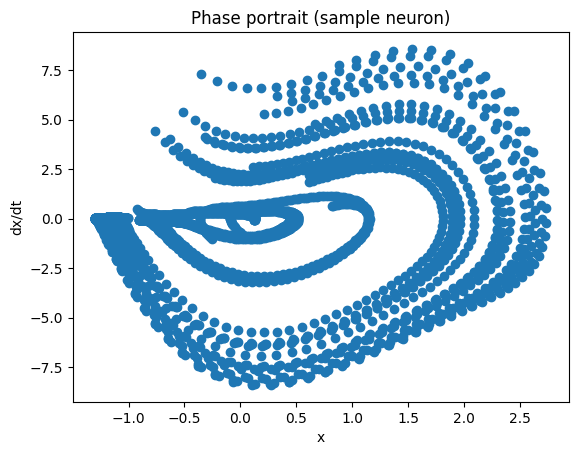

Training input shape: (5000, 15)
Training output shape: (5000, 15)


In [2]:
from hindmarsh_rose_model import hindmarsh_rose_network
from network_generator import generate_erdos_renyi_network

MY_DATA_TYPE = 'float32'
tf.keras.backend.set_floatx(MY_DATA_TYPE)

n_nodes = 5
edge_probability = 0.3
seed = 42

edge_list, adjacency, degrees = generate_erdos_renyi_network(n_nodes, edge_probability, seed=seed)

print(f'Generated ER network with {n_nodes} nodes and {edge_list.shape[0]} edges')

np.random.seed(seed)
num_traj = 20
initial_conditions = []
for _ in range(num_traj):
    x0 = np.random.uniform(-1.0, 1.0, size=n_nodes)
    y0 = np.random.uniform(-5.0, 5.0, size=n_nodes)
    z0 = np.random.uniform(1.0, 2.0, size=n_nodes)
    initial_state = np.concatenate([x0, y0, z0])
    initial_conditions.append(initial_state)

data_T = 5.0
data_dt = 0.02
myDG = DG.DataGenerator(initial_conditions, T=data_T, dt=data_dt, derivative_mode='exact')

def hr_vector_field(t, state, edge_list):
    return hindmarsh_rose_network(t, state, edge_list, coupling_strength=0.05, I=3.2)

T_arr, x_train, dx_train = myDG.generate_dataset_by_custom_ODEs(hr_vector_field, edge_list, method='RK45')

import matplotlib.pyplot as plt
plt.scatter(x_train[:, 0], dx_train[:, 0])
plt.title('Phase portrait (sample neuron)')
plt.xlabel('x')
plt.ylabel('dx/dt')
plt.show()

training_input, training_output = x_train, dx_train
training_input_for_sim = training_input.copy()

print('Training input shape:', training_input.shape)
print('Training output shape:', training_output.shape)

MY_MODEL = 'Hindmarsh-Rose network (ER)'
data_initial_conditions = initial_conditions
guess_highest_order_polynomial = 3
ode_function = hr_vector_field
network_arguments = (edge_list,)


### **1.3 Hyperparameters**

In [3]:
MINI_BATCH_SIZE = 64
learning_rate = 0.001

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [4]:
dim = training_input.shape[1]
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn)


[15, 15, 15]


## **II. Model and Training Preparation**

### **2.1 Create the SREINet Model**

In [5]:
my_activation = [lambda x: x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                 activations=my_activation,
                 weight_initializer=tf.initializers.random_normal(stddev=1e-3, seed=42),
                 data_type=MY_DATA_TYPE,
                 name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 15)]              0         
                                                                 
 SREINet (SREINet)           (None, 1)                 528       
                                                                 
Total params: 528 (2.06 KB)
Trainable params: 512 (2.00 KB)
Non-trainable params: 16 (64.00 Byte)
_________________________________________________________________


### **2.2 Loss Function**

In [6]:
LOSS_FUNCTION = 'mse'  # Options: 'mse', 'lasso', 'ridge', 'elasticnet'
loss_fn = myLoss(model, LOSS_FUNCTION)

### **2.3 Optimizer**

In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

### **2.4 Trainer**

In [8]:
np.set_printoptions(threshold=np.inf)
trainer = STLSQTrainer(model, my_optimizer, loss_fn, data_type=MY_DATA_TYPE)


## **III.Training the Model**

#### **STLSQ Parameters**

In [17]:
# STLSQ training parameters
MAX_EPOCHS_PER_ITERATION = 60  # Maximum epochs per training iteration before pruning
MAX_ITERATIONS = 1000  # Maximum number of prune-train iterations
PRUNING_THRESHOLD = 0.008  # Threshold for pruning weights
PLATEAU_WINDOW = 20  # Number of epochs to check for plateau
PLATEAU_THRESHOLD = 1e-6  # Threshold for relative loss change to be considered plateau
CONVERGENCE_THRESHOLD = 1e-10  # Threshold for convergence between iterations


In [18]:
callbacks = []
training_histories = []
weights_list = []
for i in range(training_output.shape[1]):
    print(f'Training dimension {i + 1}...')
    trainer.reset_trainer_and_model_weights(i)
    output = training_output[:, i:i+1]
    history = trainer.fit(
        training_input,
        output,
        batch_size=MINI_BATCH_SIZE,
        validation_split=0.2,
        max_epochs_per_iteration=MAX_EPOCHS_PER_ITERATION,
        max_iterations=MAX_ITERATIONS,
        pruning_threshold=PRUNING_THRESHOLD,
        plateau_window=PLATEAU_WINDOW,
        plateau_threshold=PLATEAU_THRESHOLD,
        convergence_threshold=CONVERGENCE_THRESHOLD,
        callbacks=callbacks,
        verbose=1,
        shuffle_per_epoch=False,
    )
    training_histories.append(history)
    weights_list.append([trainer.get_best_weights()])


Training dimension 1...

STLSQ Iteration 1/1000
  Iteration 1 complete: Min loss = 9.874254e-03
  Pruning: 512 → 438 nonzero weights (74 pruned, 14.5% sparse)

STLSQ Iteration 2/1000
  Iteration 2 complete: Min loss = 4.567902e-03
  Pruning: 512 → 401 nonzero weights (111 pruned, 21.7% sparse)

STLSQ Iteration 3/1000
  Iteration 3 complete: Min loss = 2.581303e-03
  Pruning: 438 → 378 nonzero weights (60 pruned, 26.2% sparse)

STLSQ Iteration 4/1000
  Iteration 4 complete: Min loss = 1.821857e-03
  Pruning: 401 → 362 nonzero weights (39 pruned, 29.3% sparse)

STLSQ Iteration 5/1000
  Iteration 5 complete: Min loss = 1.284454e-03
  Pruning: 378 → 346 nonzero weights (32 pruned, 32.4% sparse)

STLSQ Iteration 6/1000
  Iteration 6 complete: Min loss = 1.315708e-03
  Pruning: 362 → 339 nonzero weights (23 pruned, 33.8% sparse)

STLSQ Iteration 7/1000
  Iteration 7 complete: Min loss = 1.013428e-03
  Pruning: 346 → 333 nonzero weights (13 pruned, 35.0% sparse)

STLSQ Iteration 8/1000
  Iter

KeyboardInterrupt: 

## **IV. Coefficient Reconstructor (SREINet)**

In [ ]:
# Define reconstruction helpers as needed


## **V. Results**

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(training_histories[0]['loss'])
plt.title('Training loss (dimension 1)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()
